In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# %cd drive/My Drive/DL_ECON

In [1]:
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import SGD, Adam
from torchvision.utils import make_grid
from torch.utils.data import Dataset, DataLoader

from torchvision import datasets, models
import torchvision.transforms as transforms

from torchsummary import summary

import torch.nn.functional as F
from PIL import Image

In [15]:
import os
import ast
import cv2
import numpy as np
import pandas as pd
from torchvision.ops import box_iou

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [4]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Understanding Convolution

In [ ]:
# Load the color image
img_color = Image.open('./data/rambo.jpg')
# Convert to greyscale
img_gray = img_color.convert('L')

# Display the color image (left subplot)
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)  # 1 row, 2 columns, position 1
plt.imshow(img_color)
plt.title('Color Image')
plt.axis('off')

# Display the grayscale image (right subplot)
plt.subplot(1, 2, 2)  # 1 row, 2 columns, position 2
plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

# Adjust layout and show both images together
plt.tight_layout()
plt.show()

## Echo of the before Neural Networks Era

In [ ]:
# Load the color image
img_color = Image.open('./data/pisa.jpeg')
# Convert to greyscale
img_gray = img_color.convert('L')

# Convert to PyTorch tensor
transform = transforms.Compose([
    transforms.ToTensor()
])
img_tensor = transform(img_gray).unsqueeze(0)

# Define all filters
filters = {


    "Gaussian Blur": torch.tensor([
        [1,  4,  6,  4, 1],
        [4, 16, 24, 16, 4],
        [6, 24, 36, 24, 6],
        [4, 16, 24, 16, 4],
        [1,  4,  6,  4, 1]
    ], dtype=torch.float).view(1, 1, 5, 5) / 256.0,


    "Motion Blur": torch.tensor([[
        [[1, 0, 0, 0, 0],
         [0, 1, 0, 0, 0],
         [0, 0, 1, 0, 0],
         [0, 0, 0, 1, 0],
         [0, 0, 0, 0, 1]]
    ]], dtype=torch.float32) / 5.0,

    "Sobel X": torch.tensor([[
        [[-1, 0, 1],
         [-2, 0, 2],
         [-1, 0, 1]]
    ]], dtype=torch.float32),

    "Sobel Y": torch.tensor([[
        [[-1, -2, -1],
         [0, 0, 0],
         [1, 2, 1]]
    ]], dtype=torch.float32)

}

# Apply with enhanced contrast to edge-sensitive filters
enhanced_filters = ["Sobel X", "Sobel Y"]

# Apply filters with padding to maintain size
def apply_filter(image, kernel):
    return F.conv2d(image, kernel)

# Create a figure with subplots
plt.figure(figsize=(20, 15))
rows = 3
cols = 3

plt.subplot(rows, cols, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Grayscale')
plt.axis('off')

# Apply and plot filters
for i, (name, kernel) in enumerate(filters.items(), start=2):
    filtered = apply_filter(img_tensor, kernel)

    if name in enhanced_filters:
        filtered = (filtered - filtered.min()) / (filtered.max() - filtered.min())
        # Optional: Power-law (gamma) correction
        filtered = filtered ** 1.2 # Darken edges

    plt.subplot(rows, cols, i)
    plt.imshow(filtered.squeeze(), cmap='gray')
    plt.title(name)
    plt.axis('off')

filtered_x = apply_filter(img_tensor, filters['Sobel X'])
filtered_y = apply_filter(img_tensor, filters['Sobel Y'])
filtered_xy = filtered_x + filtered_y

plt.subplot(rows, cols, i+1)
plt.imshow(filtered_xy.squeeze(), cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.tight_layout()
plt.show()

# Image Classification

## FMNIST Dataset

In [ ]:
data_folder = './data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)


tr_images = fmnist.data
tr_targets = fmnist.targets


val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

### Classes visualisation

In [ ]:
def visualize_classes(images, labels, classes, num_classes=10):
    plt.figure(figsize=(12, 6))

    for class_id in range(num_classes):
        # Find indices of all images belonging to the current class
        class_indices = (labels == class_id).nonzero().squeeze()

        # Randomly select one image from this class
        random_idx = np.random.choice(class_indices)
        img = images[random_idx]

        # Plot the image
        plt.subplot(2, 5, class_id + 1)  # 2 rows, 5 columns
        plt.imshow(img.numpy(), cmap='gray')
        plt.title(f'Class: {classes[class_id]}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function with data
visualize_classes(tr_images, tr_targets, fmnist.classes)

In [ ]:
def img_pixel_superimpose(img, ax):
    w, h = img.shape
    color_map = plt.colormaps['gray_r']  # gray_reversed
    ax.imshow(img, cmap='gray')
    for x in range(w):
        for y in range(h):
            color = color_map(img[x][y])
            ax.annotate(str(img[x][y]), xy=(y,x), horizontalalignment='center', verticalalignment='center',
                        color=color)
            plt.axis(False)

# torch.manual_seed(42)

fig = plt.figure(figsize = (11,11))
ax0 = fig.add_subplot(1, 1, 1)

rand_ind = torch.randint(0, len(tr_images), size=[1]).item()

img0 = tr_images.data[rand_ind]
img0 = img0.numpy()
img_pixel_superimpose(img0, ax0)

## Translation Issues

### Simple MLP

In [ ]:
# Define dataset class
class FMNISTDataset(Dataset):
    def __init__(self, images, targets, transform=None):
        self.images = images.float()/255
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.targets[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Define model
class SimpleMLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=1000, num_classes=10):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the input
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Initialize model, loss function, and optimizer
model = SimpleMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### MLP Summary

In [ ]:
summary(model, input_size=(1, 28, 28));

In [ ]:
# Create data loaders
def get_data_loaders(tr_images, tr_targets, val_images, val_targets, batch_size=32):
    train_dataset = FMNISTDataset(tr_images, tr_targets)
    val_dataset = FMNISTDataset(val_images, val_targets)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=len(val_images), shuffle=False)

    return train_loader, val_loader

# Training and evaluation functions
def train_epoch(model, train_loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in train_loader:
        x, y = batch
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in val_loader:
            x, y = batch
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# Main training loop
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=5):
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(num_epochs):
        # Training
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Accuracy: {val_acc:.2f}%')
        print('-' * 50)

    return {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies
    }

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Plot training & validation loss values
    plt.subplot(1, 2, 1)
    plt.plot(history['train_losses'], label='Train Loss')
    plt.plot(history['val_losses'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid()
    plt.legend()

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 2)
    plt.plot(history['train_accuracies'], label='Train Accuracy')
    plt.plot(history['val_accuracies'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid()
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
train_loader, val_loader = get_data_loaders(tr_images, tr_targets, val_images, val_targets)
history = train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=5)

In [ ]:
plot_history(history)

In [ ]:
def visualize_sample_prediction(model, images, targets, classes, index=None, device='cpu'):
    """Visualize a random sample with model predictions."""
    # Select random image if no index provided
    if index is None:
        index = np.random.randint(len(images))

    # Prepare image and display
    image = images[index]
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {classes[targets[index]]}")
    plt.axis('off')
    plt.show()

    # Prepare image for model - add batch dimension
    img_tensor = (image/255.).view(1, -1).to(device).float()  # Changed to (1, 784)

    # Get model predictions
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.nn.functional.softmax(logits, dim=1).cpu().numpy()[0]  # Get first (and only) batch element

    # Display predictions
    print(f"\nModel predictions for sample {index}:")
    for i, (class_name, prob) in enumerate(zip(classes, probs)):
        print(f"{class_name}: {prob:.2%}{' ← CORRECT' if i == targets[index] else ''}")

In [ ]:
# 1. Visualize a single prediction
visualize_sample_prediction(model, tr_images, tr_targets, fmnist.classes, index=100, device=device)

In [ ]:
def analyze_translation_effects(model, image, target, classes, device='cpu', shift_range=(-5, 6)):
    """Analyze how translation affects model predictions."""
    # Prepare base image
    original_img = (image.float()/255.).view(28, 28).numpy()  # Convert to float and numpy array

    shifts = range(shift_range[0], shift_range[1])

    # Collect predictions for each shift
    predictions = []
    for px in shifts:
        # Apply translation
        shifted_img = np.roll(original_img, px, axis=1)

        # Get model prediction - add batch dimension
        img_tensor = torch.tensor(shifted_img).view(1, -1).to(device).float()
        with torch.no_grad():
            logits = model(img_tensor)
            probs = torch.nn.functional.softmax(logits, dim=1).cpu().numpy()[0]
        predictions.append(probs)

        # Display shifted images (optional)
        if abs(px) <= 5:  # Only show small shifts for clarity
            plt.figure(figsize=(2, 2))
            plt.imshow(shifted_img, cmap='gray')
            plt.title(f"Shift: {px} px")
            plt.axis('off')
            plt.show()

    # Create heatmap visualization
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        np.array(predictions),
        annot=True,
        fmt='.1%',
        xticklabels=classes,
        yticklabels=[f"{i} px" for i in shifts],
        cmap='viridis',
        cbar=False
    )
    plt.title(f"Class Probabilities vs Horizontal Translation\n(True class: {classes[target]})")
    plt.xlabel("Classes")
    plt.ylabel("Translation Amount")
    plt.tight_layout()
    plt.show()

In [ ]:
# 2. Analyze translation effects
sample_idx = 1000  # or any other index
analyze_translation_effects(
    model=model,
    image=tr_images[sample_idx],
    target=tr_targets[sample_idx],
    classes=fmnist.classes,
    device=device,
    shift_range=(-5, 6)
)

### Simple CNN

In [ ]:
# Define dataset class
class FMNISTDataset(Dataset):
    def __init__(self, images, targets, transform=None):
        self.images = images.float()/255
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.targets[idx]

        if self.transform:
            image = self.transform(image)
        else:
            # Add channel dimension if no transform is provided
            image = image.unsqueeze(0)  # Shape: [1, 28, 28]

        return image, label

# Define CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3200, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.model(x)

# Initialize model, loss function, and optimizer
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### CNN summary

In [ ]:
summary(model, input_size=(1, 28, 28));

In [ ]:
train_loader, val_loader = get_data_loaders(tr_images, tr_targets, val_images, val_targets)
history = train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=5)

In [ ]:
plot_history(history)

In [ ]:
def visualize_sample_prediction(model, images, targets, classes, index=None, device='cpu'):
    """Visualize a random sample with model predictions."""
    # Select random image if no index provided
    if index is None:
        index = np.random.randint(len(images))

    # Prepare image and display
    image = images[index]
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {classes[targets[index]]}")
    plt.axis('off')
    plt.show()

    # Prepare image for model - add channel and batch dimensions
    img_tensor = (image.float()/255.).unsqueeze(0).unsqueeze(0).to(device)  # Shape: [1, 1, 28, 28]

    # Get model predictions
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.nn.functional.softmax(logits, dim=1).cpu().numpy()[0]  # Get first (and only) batch element

    # Display predictions
    print(f"\nModel predictions for sample {index}:")
    for i, (class_name, prob) in enumerate(zip(classes, probs)):
        print(f"{class_name}: {prob:.2%}{' ← CORRECT' if i == targets[index] else ''}")

# 1. Visualize a single prediction
sample_idx = 1000  # or any other index
visualize_sample_prediction(model, tr_images, tr_targets, fmnist.classes, index=sample_idx, device=device)

def analyze_translation_effects(model, image, target, classes, device='cpu', shift_range=(-5, 6)):
    """Analyze how translation affects model predictions."""
    # Prepare base image
    original_img = (image.float()/255.).view(28, 28).numpy()  # Convert to float and numpy array

    shifts = range(shift_range[0], shift_range[1])

    # Collect predictions for each shift
    predictions = []
    for px in shifts:
        # Apply translation
        shifted_img = np.roll(original_img, px, axis=1)

        # Get model prediction - add channel and batch dimensions
        img_tensor = torch.tensor(shifted_img).unsqueeze(0).unsqueeze(0).to(device).float()  # Shape: [1, 1, 28, 28]
        with torch.no_grad():
            logits = model(img_tensor)
            probs = torch.nn.functional.softmax(logits, dim=1).cpu().numpy()[0]
        predictions.append(probs)

    # Create heatmap visualization
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        np.array(predictions),
        annot=True,
        fmt='.1%',
        xticklabels=classes,
        yticklabels=[f"{i} px" for i in shifts],
        cmap='viridis',
        cbar=False
    )
    plt.title(f"Class Probabilities vs Horizontal Translation\n(True class: {classes[target]})")
    plt.xlabel("Classes")
    plt.ylabel("Translation Amount")
    plt.tight_layout()
    plt.show()

# 2. Analyze translation effects
analyze_translation_effects(
    model=model,
    image=tr_images[sample_idx],
    target=tr_targets[sample_idx],
    classes=fmnist.classes,
    device=device,
    shift_range=(-5, 6)
)

# Transfer Learning & Feature Maps

## Model inspection with hook functions

In [ ]:
for i in model.children():
  display(i)

In [ ]:
def hook_fn(module, input, output):
    global layer_output
    layer_output = output

In [ ]:
handle = model.model[0].register_forward_hook(hook_fn)

In [ ]:
# White noise
img_noise = torch.randn(1, 1, 28, 28)
img_noise = img_noise.to(device)

# Forward pass the image through the model
model.eval()

with torch.inference_mode():
    preds = model(img_noise)

layer_output = layer_output.squeeze()

In [ ]:
rows, cols = 3, 5

fig = plt.figure(figsize=(10, 6))

for i in range(1, (rows * cols) + 1):
    feature_map = layer_output[i-1, :, :].cpu().numpy()
    fig.add_subplot(rows, cols, i)
    plt.imshow(feature_map, cmap='viridis')
    plt.tight_layout()
    plt.axis(False)

## VGG16 Model

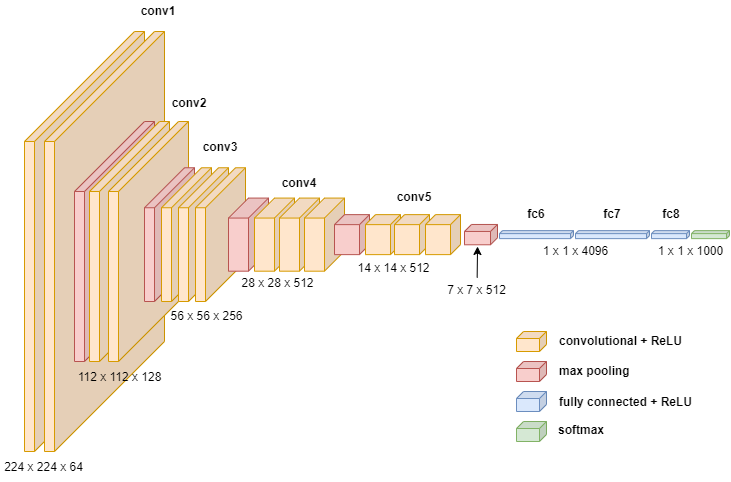

In [ ]:
# load pretrained model and register it to device
model_vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).to(device)

# Fetch the summary of the model
summary(model_vgg16, input_size=(3, 224, 224))

In [ ]:
def viz_plain(layer_num, img, model, device):

    #transforms
    transforms_imagenet = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x[:3] if x.shape[0] == 4 else x),
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.Normalize(
                mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)
            ),
        ]
    )

    img = transforms_imagenet(img).unsqueeze_(dim=0)

    # device-agnostic
    model = model.to(device)
    img = img.to(device)

    feature_maps = []
    def hook_fn(module, input, output):
        feature_maps.append(output)

    layer = model_vgg16.features[layer_num]
    handle = layer.register_forward_hook(hook_fn)

    # Forward pass the image through the model
    model.eval()
    with torch.inference_mode():
        preds = model(img)

    # Print the predicted class
    pred_cls_idx = preds.argmax(dim=1)
    classes_imgnet = models.VGG16_Weights.IMAGENET1K_V1.meta["categories"]
    pred_cls = classes_imgnet[pred_cls_idx]
    print(pred_cls)

    # Plot the feature maps
    layer_output = feature_maps[0].squeeze()
    rows, cols = 4, 6
    fig = plt.figure(figsize=(12, 8))
    for i in range(1, (rows * cols) + 1):
        feature_map = layer_output[i-1, :, :].cpu().numpy()
        fig.add_subplot(rows, cols, i)
        plt.imshow(feature_map, cmap='viridis')
        #plt.tight_layout()
        plt.axis(False)

In [ ]:
img_warplane = Image.open("./data/airplane.png")
display(np.asarray(img_warplane).shape)
display(img_warplane)

In [ ]:
viz_plain(10, img_warplane, model_vgg16, device)

## Brain Tumor MRI Classification

In [ ]:
# Define transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Load datasets
train_data = datasets.ImageFolder(root='./data/BrainTumorMRIClassification/Training', transform=train_transform)
test_data = datasets.ImageFolder(root='./data/BrainTumorMRIClassification/Testing', transform=test_transform)

In [ ]:
def show_batch(dataset, batch_size=32):

    loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

    # Get a batch
    images, labels = next(iter(loader))

    # Print label-class mapping
    print("\nLabel-Class Mapping:")
    for label_idx, class_name in enumerate(dataset.classes):
        print(f"{label_idx}: {class_name}")

    # Print labels in grid-matching format
    print("\nCurrent Batch Labels:")
    nrow = 8
    print(labels.numpy().reshape(-1, nrow))

    # Make grid
    grid = make_grid(images, nrow=nrow, normalize=True, scale_each=True)

    # Plot
    plt.figure(figsize=(12, 6))
    plt.imshow(grid.permute(1, 2, 0))  # (C, H, W) → (H, W, C)
    plt.title("Batch of MRI Images")
    plt.axis("off")
    plt.show()

show_batch(train_data)

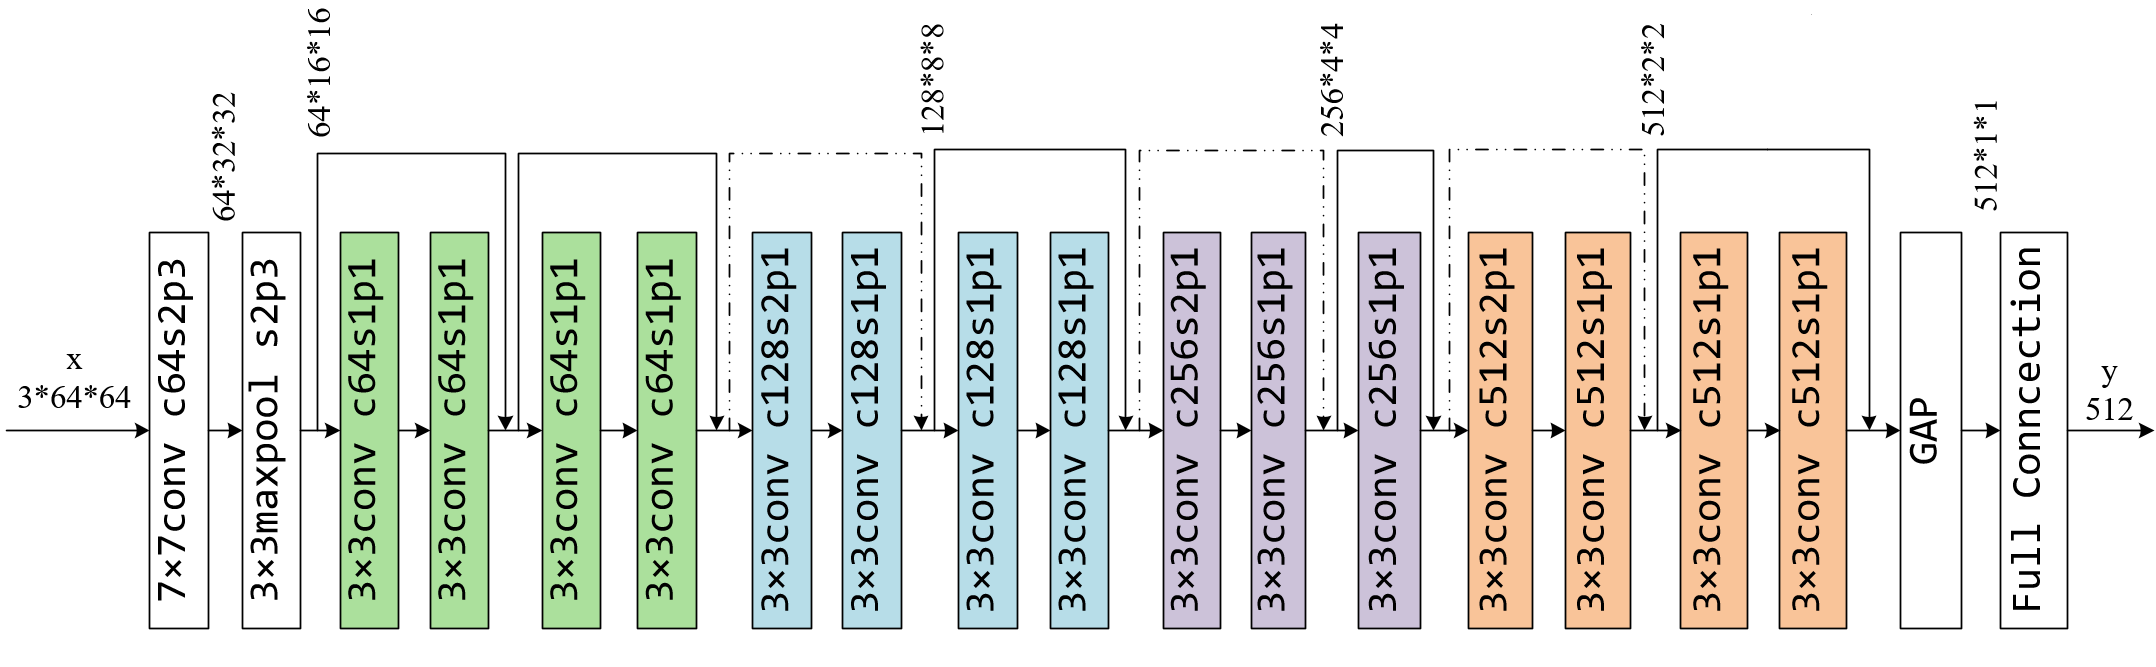

In [ ]:
# Load pre-trained ResNet18
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(device)

In [ ]:
# Create dataloaders
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

In [ ]:
# model_resnet18.parameters
# summary(model_resnet18, input_size=(3, 224, 224))

In [ ]:
# Freeze all layers (optional for fine-tuning)
for param in model_resnet18.parameters():
    param.requires_grad = False

for param in model_resnet18.layer3.parameters():
    param.requires_grad = True

# for param in model_resnet18.layer4.parameters():
#     param.requires_grad = True

# for name, module in model_resnet18.named_modules():
#     if isinstance(module, nn.BatchNorm2d):
#         for param in module.parameters():
#             param.requires_grad = True

In [ ]:
# Modify the final fully connected layer
num_features = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_features, 4).to(device)  # 4 output classes

# Define Loss Function & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet18.parameters(), lr=1e-3)  # Fixed: Use model_resnet18

In [ ]:
def evaluate_model(model, test_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)  # Move to device
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    test_loss = running_loss / len(test_loader)
    return test_acc, test_loss

In [ ]:
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=10):
    # Initialize history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(epochs):
    # for epoch in tqdm(range(epochs)):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track stats
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Calculate epoch metrics
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        val_acc, val_loss = evaluate_model(model, test_loader, criterion)

        # Update history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # # Print epoch summary
        print(f'\nEpoch {epoch+1}/{epochs}:')
        print(f'Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Accuracy: {val_acc:.2f}%')
        print('-' * 50)

    return history  

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
history = train_model(model_resnet18, train_loader, test_loader, criterion, optimizer, epochs=10)
plot_history(history)

# Global Wheat Detection

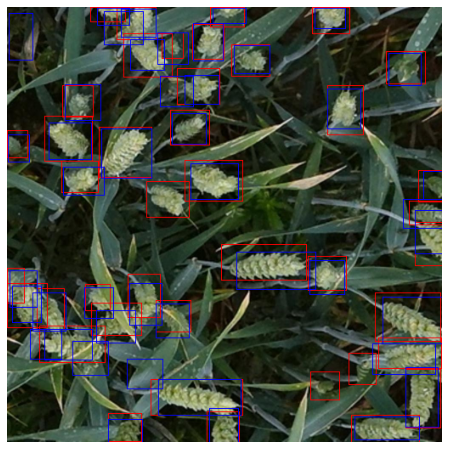

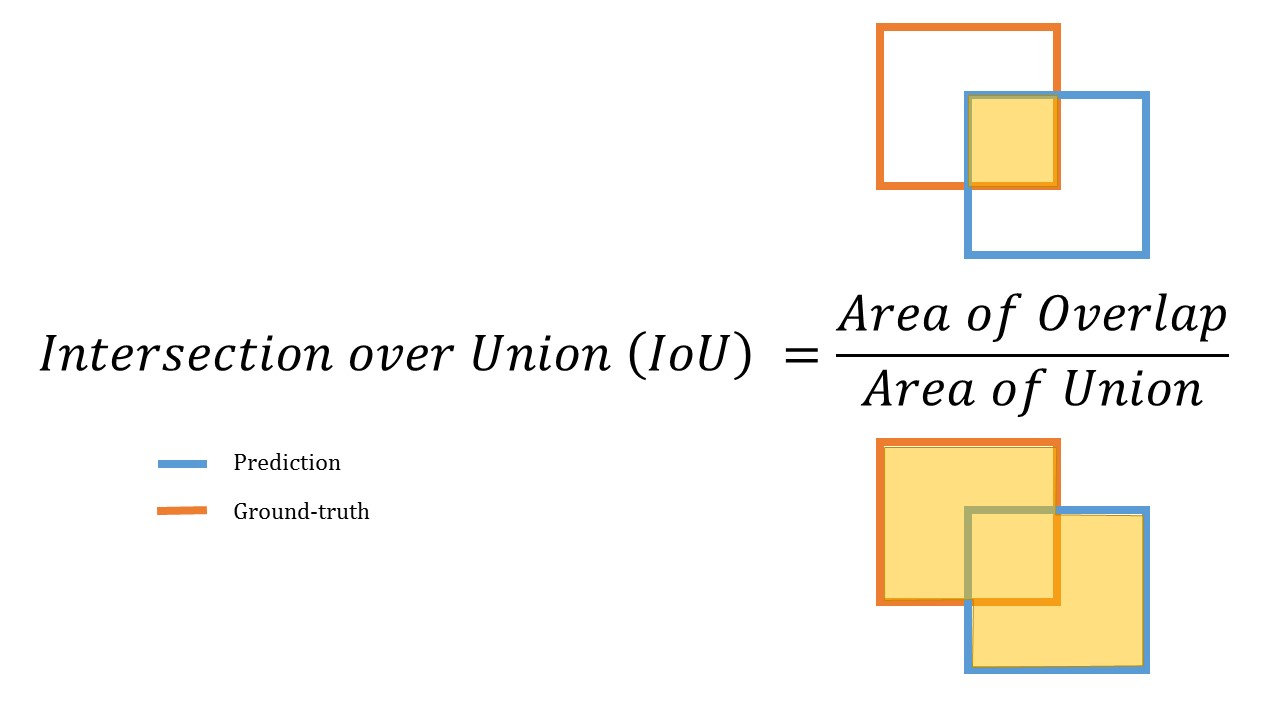

## Load annotations

In [5]:
df = pd.read_csv("./data/global-wheat-detection/train.csv")

# Group boxes by image_id (since one image can have multiple boxes)
annotations = df.groupby('image_id')['bbox'].apply(list).reset_index(name='bboxes')

In [6]:
annotations.head()

,image_id,bboxes
0,00333207f,"[[0, 654, 37, 111], [0, 817, 135, 98], [0, 192..."
1,005b0d8bb,"[[765.0, 879.0, 116.0, 79.0], [84.0, 539.0, 15..."
2,006a994f7,"[[437.0, 988.0, 98.0, 36.0], [309.0, 527.0, 11..."
3,00764ad5d,"[[89.0, 256.0, 113.0, 107.0], [216.0, 282.0, 1..."
4,00b5fefed,"[[709.0, 97.0, 204.0, 105.0], [775.0, 250.0, 1..."


## Parse Bounding Boxes

In [7]:
# Convert [xmin, ymin, width, height] to [xmin, ymin, xmax, ymax]
def parse_bbox(bbox_str):
    bbox = ast.literal_eval(bbox_str)  # Convert string to list
    x, y, w, h = bbox
    return [x, y, x + w, y + h]  # Convert to xmin, ymin, xmax, ymax

annotations['bboxes'] = annotations['bboxes'].apply(
    lambda x: [parse_bbox(box) for box in x]
)

In [8]:
annotations.head()

,image_id,bboxes
0,00333207f,"[[0, 654, 37, 765], [0, 817, 135, 915], [0, 19..."
1,005b0d8bb,"[[765.0, 879.0, 881.0, 958.0], [84.0, 539.0, 2..."
2,006a994f7,"[[437.0, 988.0, 535.0, 1024.0], [309.0, 527.0,..."
3,00764ad5d,"[[89.0, 256.0, 202.0, 363.0], [216.0, 282.0, 3..."
4,00b5fefed,"[[709.0, 97.0, 913.0, 202.0], [775.0, 250.0, 9..."


## Create a Custom Dataset Class

In [9]:
class WheatDataset(Dataset):
    # def __init__(self, dataframe, image_dir, transforms=None):
    #     self.dataframe = dataframe
    #     self.image_dir = image_dir
    #     self.transforms = transforms

    def __init__(self, dataframe, image_dir, transforms=None, sample_fraction=0.1, seed=42):
        self.dataframe = dataframe.sample(frac=sample_fraction, random_state=seed)
        self.image_dir = image_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.dataframe)

    
    def __getitem__(self, idx):
        image_id = self.dataframe.iloc[idx]['image_id']
        image_path = f"{self.image_dir}/{image_id}.jpg"
        image = cv2.imread(image_path)
        
        if image is None:
            raise FileNotFoundError(f"Could not load image at path: {image_path}")
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
        image = image.astype(np.float32) / 255.0  # Normalize to [0, 1]
        image = torch.from_numpy(image).permute(2, 0, 1)  # (H, W, C) → (C, H, W)
    
        # Get bounding boxes and labels
        boxes = self.dataframe.iloc[idx]['bboxes']
        num_objs = len(boxes)
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.ones((num_objs,), dtype=torch.int64)  # All wheat heads are class "1"
    
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }
    
        if self.transforms:
            sample = {
                'image': image,
                'bboxes': target['boxes'],
                'labels': labels
            }
            sample = self.transforms(**sample)
            image = sample['image']
            target['boxes'] = torch.stack(tuple(map(torch.tensor, zip(*sample['bboxes'])))).permute(1, 0).float()
    
        return image, target

## Load Faster R-CNN Model

In [10]:
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = models.detection.fasterrcnn_resnet50_fpn(weights=models.detection.FasterRCNN_ResNet50_FPN_Weights.COCO_V1)
    
    # Replace the classifier head (for our number of classes)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    return model

model_FRCNN = get_model(num_classes=2)

## Train the Model

### Define Data Loaders

In [11]:
# dataset = WheatDataset(annotations, "./data/global-wheat-detection/train/")
dataset = WheatDataset(annotations, "./data/global-wheat-detection/train/", sample_fraction=0.1)
data_loader = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

## Training Loop

In [12]:
model_FRCNN.to(device)

# Freeze all layers (optional for fine-tuning)
for param in model_FRCNN.parameters():
    param.requires_grad = False

for param in model_FRCNN.roi_heads.parameters():
    param.requires_grad = True

params = [p for p in model_FRCNN.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

num_epochs = 5

for epoch in range(num_epochs):
    model_FRCNN.train()
    for images, targets in data_loader:
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model_FRCNN(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    print(f"Epoch {epoch}, Loss: {losses.item()}")

Epoch 0, Loss: 4.5359320640563965
Epoch 1, Loss: 4.3718438148498535
Epoch 2, Loss: 2.475694417953491
Epoch 3, Loss: 3.0704691410064697
Epoch 4, Loss: 3.370185375213623


In [13]:
def evaluate_model(model, data_loader, device):
    metric = MeanAveragePrecision()
    model.eval()
    
    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            predictions = model(images)
            metric.update(predictions, targets)
    
    results = metric.compute()
    print(f"mAP: {results['map']:.4f}")
    print(f"mAP_50: {results['map_50']:.4f}")
    print(f"mAP_75: {results['map_75']:.4f}")
    return results

In [14]:
evaluate_model(model_FRCNN, data_loader, device)

mAP: 0.1325
mAP_50: 0.3359
mAP_75: 0.0754


{'map': tensor(0.1325),
 'map_50': tensor(0.3359),
 'map_75': tensor(0.0754),
 'map_small': tensor(0.0083),
 'map_medium': tensor(0.1351),
 'map_large': tensor(0.1226),
 'mar_1': tensor(0.0110),
 'mar_10': tensor(0.0842),
 'mar_100': tensor(0.1881),
 'mar_small': tensor(0.0301),
 'mar_medium': tensor(0.1836),
 'mar_large': tensor(0.2144),
 'map_per_class': tensor(-1.),
 'mar_100_per_class': tensor(-1.),
 'classes': tensor(1, dtype=torch.int32)}

Visualizing predictions for image: 51b3e36ab


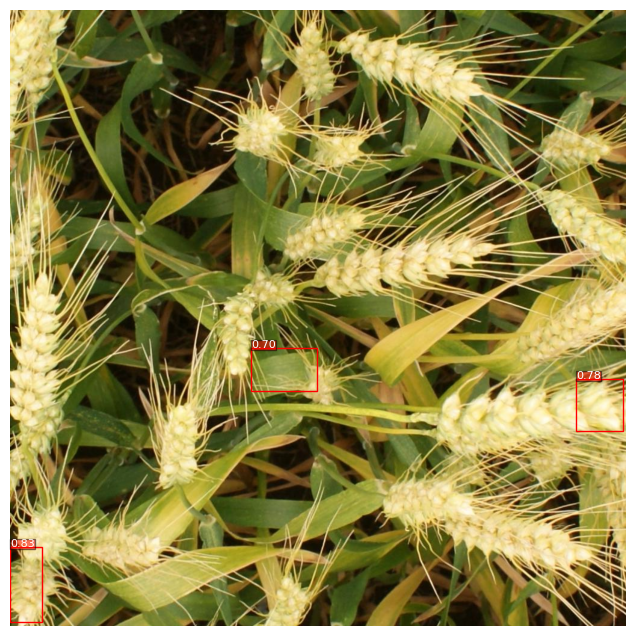

In [16]:
import matplotlib.patches as patches

def visualize_predictions(image, predictions, confidence_threshold=0.7):

    # Convert image to numpy and denormalize if needed
    img = image.permute(1, 2, 0).cpu().numpy()
    if img.max() <= 1.0:  # if normalized
        img = (img * 255).astype('uint8')
    
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img)
    
    boxes = predictions['boxes'].cpu().numpy()
    scores = predictions['scores'].cpu().numpy()
    
    # Filter boxes by confidence threshold
    keep = scores >= confidence_threshold
    boxes = boxes[keep]
    scores = scores[keep]
    
    for box, score in zip(boxes, scores):
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin), xmax-xmin, ymax-ymin,
            linewidth=1, edgecolor='r', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            xmin, ymin, f'{score:.2f}',
            color='white', fontsize=8,
            bbox=dict(facecolor='red', alpha=0.5, pad=0)
        )
    
    plt.axis('off')
    plt.show()

class TestDataset(Dataset):
    def __init__(self, image_dir, transforms=None):
        self.image_dir = image_dir
        self.image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
        self.transforms = transforms
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_id = os.path.splitext(self.image_files[idx])[0]
        
        # Convert to tensor and normalize
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        
        if self.transforms:
            image = self.transforms(image=image)['image']
            
        return image, image_id

# Create test dataset and loader
test_dataset = TestDataset("./data/global-wheat-detection/test/")
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Put model in evaluation mode
model_FRCNN.eval()

# Select a random image from test set to visualize
import random
idx_to_visualize = random.randint(0, len(test_dataset)-1)

# Get the image and make prediction
image, image_id = test_dataset[idx_to_visualize]
with torch.no_grad():
    prediction = model_FRCNN([image.to(device)])[0]

# Visualize the predictions
print(f"Visualizing predictions for image: {image_id}")
visualize_predictions(image, prediction)